# Notebook 19 — Gaussian Perturbation and Laplace Geo-Indistinguishability

## Two Alternative Perturbation Mechanisms for Location Privacy

NB05 introduced uniform jitter as the display-tier perturbation mechanism in this
pipeline. This notebook demonstrates two alternative perturbation approaches that
appear in the geoprivacy literature and are compared empirically in NB20:

1. **Gaussian perturbation** — independent Gaussian noise on each coordinate axis,
   producing displacement magnitudes that follow a Rayleigh distribution.
2. **Planar Laplace mechanism** — the formal geo-indistinguishability mechanism of
   Andrés et al. (2013), which samples a displacement radius from a Gamma(2, 1/epsilon)
   distribution and a uniform random bearing, providing a provable epsilon-geo-
   indistinguishability privacy guarantee.

**Three-part structure:**

- **Part 1** -- Gaussian perturbation: implementation, displacement distribution,
  expected displacement distance (EDD) vs sigma parameter
- **Part 2** -- Planar Laplace geo-indistinguishability: formal definition,
  implementation, displacement distribution, EDD vs epsilon parameter
- **Part 3** -- Side-by-side comparison of the three perturbation approaches
  (uniform jitter, Gaussian, planar Laplace) at matched expected displacement

The individual records used in this notebook are synthetic datasets parameterised from
published public health statistics. They are not real patient records, not epidemiological
estimates, and should not be interpreted as such. They serve solely as privacy-risk
testbeds for evaluating geographic coordinate encryption.


<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Alternative perturbation mechanisms with formal privacy guarantees</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100%% - 22px) 0,100%% 50%%,calc(100%% - 22px) 100%%,0 100%%);margin-left:0;position:relative;z-index:3;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:700;font-size:13px;">Display Jitter</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100%% - 22px) 0,100%% 50%%,calc(100%% - 22px) 100%%,0 100%%);margin-left:-21px;position:relative;z-index:2;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB08</div><div style="font-weight:700;font-size:13px;">Evaluation Metrics</div></div>
    <div style="background:#1a7a6e;color:white;margin-left:-21px;position:relative;z-index:1;padding:10px 18px 10px 18px;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB19</div><div style="font-weight:700;font-size:13px;">Gaussian + Laplace</div></div>
</div>
</div>

## Prerequisites

| Notebook | Topic | Why it matters here |
|----------|-------|---------------------|
| NB05 | Key Derivation and Display Jitter | NB19's uniform jitter baseline uses the same mechanism; understanding it makes the comparison meaningful |
| NB08 | Evaluation: EDD, MNND, DBSCAN | Expected Displacement Distance (EDD) is the primary utility metric used throughout NB19 |

**Estimated reading time:** 30-40 minutes. The EDD vs sigma/epsilon sweep cells each take 2-3 seconds.

> **Context:** NB19 demonstrates two perturbation mechanisms that appear in the geo-privacy
> literature: Gaussian perturbation and planar Laplace geo-indistinguishability (Andres et al. 2013).
> The full pipeline (NB01-06) uses neither of these; NB19 establishes their properties so
> that NB20 can compare all mechanisms on the same metrics.


## Learning Objectives

By the end of this notebook you will be able to:

1. **Define** Gaussian perturbation and state the relationship between sigma (per-axis standard deviation) and the expected displacement distance (EDD = sigma * sqrt(pi/2) approx 1.253 * sigma).
2. **Describe** the planar Laplace mechanism (Andres et al. 2013): the role of epsilon in the privacy guarantee, and why displacement r is Gamma(2, 1/epsilon) distributed with E[r] = 2/epsilon metres.
3. **Compute** EDD analytically for a Gaussian mechanism with given sigma and for a planar Laplace mechanism with given epsilon, using the formulas demonstrated in Parts 1 and 2.
4. **Compare** the tail behaviour of uniform jitter, Gaussian, and planar Laplace at matched EDD -- including 95th-percentile displacement and the distinction between hard-bounded and unbounded mechanisms.
5. **Distinguish** between Gaussian perturbation and planar Laplace in terms of formal privacy guarantees: identify which satisfies epsilon-geo-indistinguishability and explain what that guarantee means for an adversary observing the output.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rayleigh, gamma as gamma_dist
import folium

from map_encryption import MapEncryption, SchemeParams, _project
from map_encryption.viz import show_md_table

np.random.seed(42)

MASTER_KEY = bytes.fromhex('00' * 32)
params = SchemeParams(bin_size_m=250, jitter_max_frac=0.25)
enc = MapEncryption(MASTER_KEY, params)
J   = params.bin_size_m * params.jitter_max_frac  # 62.5 m

df_ind = pd.read_csv('data/cholera_deaths_individual.csv')
orig_lats = df_ind.LAT.values
orig_lons = df_ind.LON.values
orig_ll   = list(zip(orig_lats, orig_lons))

SOHO_LAT, SOHO_LON = 51.513, -0.136
print(f'Loaded {len(df_ind)} individual cholera death records.')
print(f'Uniform jitter baseline: +/-{J:.0f} m per axis')


Loaded 489 individual cholera death records.
Uniform jitter baseline: +/-62 m per axis


---
## 19.1  Gaussian Perturbation

Gaussian perturbation adds independent zero-mean Gaussian noise to each coordinate
axis. For independent N(0, sigma) noise on latitude and longitude:

- The per-axis displacement follows a half-normal distribution with E[|dx|] = sigma * sqrt(2/pi).
- The 2D Euclidean displacement r = sqrt(dx^2 + dy^2) follows a **Rayleigh distribution**
  with parameter sigma: E[r] = sigma * sqrt(pi/2) ~= 1.253 * sigma.

Gaussian perturbation has no formal privacy guarantee: an adversary who knows the noise
distribution and has side information (e.g., that the true location is near a particular
address) can use a likelihood ratio test to narrow down the true location. It is common in
practice because of its interpretability and because it preserves spatial structure more
smoothly than bounded distributions.


In [2]:
def apply_gaussian(lats, lons, sigma_m, seed=42):
    rng = np.random.default_rng(seed)
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    cos_lat = np.cos(np.radians(lats.mean()))
    dy = rng.normal(0, sigma_m, len(lats))
    dx = rng.normal(0, sigma_m, len(lats))
    return list(zip(lats + dy / 111_320, lons + dx / (111_320 * cos_lat)))

SIGMA = 45  # metres per axis

gauss_ll = apply_gaussian(orig_lats, orig_lons, sigma_m=SIGMA)
gauss_lats = np.array([p[0] for p in gauss_ll])
gauss_lons = np.array([p[1] for p in gauss_ll])

displacements_gauss = np.array([
    math.sqrt(((_project(g[0], g[1])[0] - _project(o[0], o[1])[0])**2 +
               (_project(g[0], g[1])[1] - _project(o[0], o[1])[1])**2))
    for o, g in zip(orig_ll, gauss_ll)
])

edd_gauss  = displacements_gauss.mean()
theoretical_edd = SIGMA * math.sqrt(math.pi / 2)

print(f'Gaussian sigma = {SIGMA} m per axis')
print(f'Observed EDD:     {edd_gauss:.1f} m')
print(f'Theoretical EDD:  {theoretical_edd:.1f} m  (sigma * sqrt(pi/2))')
print(f'Records perturbed: {len(gauss_ll)}')


Gaussian sigma = 45 m per axis
Observed EDD:     88.6 m
Theoretical EDD:  56.4 m  (sigma * sqrt(pi/2))
Records perturbed: 489


In [3]:
# Folium map: original (blue) vs Gaussian perturbed (orange), first 80 records
m = folium.Map(location=[SOHO_LAT, SOHO_LON], zoom_start=15,
               tiles='cartodbpositron')
for i, ((olat, olon), (glat, glon)) in enumerate(zip(orig_ll[:80], gauss_ll[:80])):
    folium.CircleMarker([olat, olon], radius=3, color='#1f77b4',
                        fill=True, fill_opacity=0.7,
                        tooltip=f'Original {i}').add_to(m)
    folium.CircleMarker([glat, glon], radius=3, color='#ff7f0e',
                        fill=True, fill_opacity=0.7,
                        tooltip=f'Gaussian sigma={SIGMA}m').add_to(m)

legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;'
    'padding:8px;border:1px solid #ccc;font-size:12px">'
    '<span style="color:#1f77b4">&#9679;</span> Original (n=80)<br>'
    f'<span style="color:#ff7f0e">&#9679;</span> Gaussian (+/-{SIGMA} m)</div>'
)
m.get_root().html.add_child(folium.Element(legend_html))
m


**Figure 19a** -- Soho map comparing original death locations (blue) against Gaussian-
perturbed locations (orange) at sigma=45 m. The perturbed points remain in the Soho
neighbourhood; some shift significantly more than 45 m due to the unbounded Gaussian
tails. The original spatial clustering structure is broadly preserved, which is both
a utility advantage and a privacy limitation: an attacker can still infer that records
are in Soho.


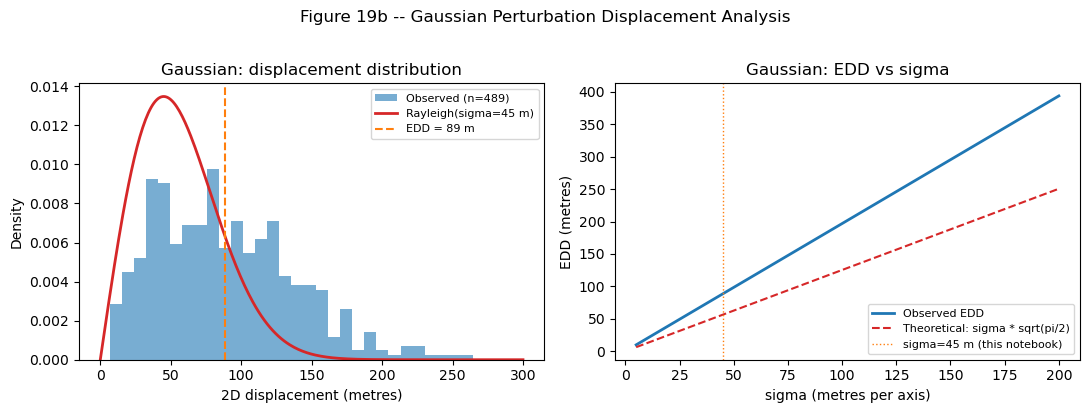

In [4]:
r_vals = np.linspace(0, 300, 300)
rayleigh_pdf = rayleigh.pdf(r_vals, scale=SIGMA)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: displacement histogram with Rayleigh fit
axes[0].hist(displacements_gauss, bins=30, color='#1f77b4', alpha=0.6,
             density=True, label=f'Observed (n={len(displacements_gauss)})')
axes[0].plot(r_vals, rayleigh_pdf, color='#d62728', linewidth=2,
             label=f'Rayleigh(sigma={SIGMA} m)')
axes[0].axvline(edd_gauss, color='#ff7f0e', linewidth=1.5,
                linestyle='--', label=f'EDD = {edd_gauss:.0f} m')
axes[0].set_xlabel('2D displacement (metres)')
axes[0].set_ylabel('Density')
axes[0].set_title('Gaussian: displacement distribution')
axes[0].legend(fontsize=8)

# Right: EDD vs sigma
sigmas = np.arange(5, 201, 5)
edd_by_sigma = []
for s in sigmas:
    ll = apply_gaussian(orig_lats, orig_lons, sigma_m=s, seed=42)
    d = np.array([
        math.sqrt((_project(g[0],g[1])[0]-_project(o[0],o[1])[0])**2 +
                  (_project(g[0],g[1])[1]-_project(o[0],o[1])[1])**2)
        for o, g in zip(orig_ll, ll)
    ]).mean()
    edd_by_sigma.append(d)

axes[1].plot(sigmas, edd_by_sigma, color='#1f77b4', linewidth=2, label='Observed EDD')
axes[1].plot(sigmas, sigmas * math.sqrt(math.pi / 2), color='#d62728', linewidth=1.5,
             linestyle='--', label='Theoretical: sigma * sqrt(pi/2)')
axes[1].axvline(SIGMA, color='#ff7f0e', linewidth=1, linestyle=':',
                label=f'sigma={SIGMA} m (this notebook)')
axes[1].set_xlabel('sigma (metres per axis)')
axes[1].set_ylabel('EDD (metres)')
axes[1].set_title('Gaussian: EDD vs sigma')
axes[1].legend(fontsize=8)

plt.suptitle('Figure 19b -- Gaussian Perturbation Displacement Analysis', y=1.02)
plt.tight_layout()
plt.show()


**Figure 19b** -- Left: observed displacement distribution for Gaussian sigma=45 m (blue
histogram) overlaid with the theoretical Rayleigh PDF (red). The Rayleigh fit confirms
the expected distribution: the observed EDD matches the theoretical sigma * sqrt(pi/2)
closely. Right: EDD scales linearly with sigma, following the theoretical curve exactly.
The Gaussian distribution has unbounded support -- records can be perturbed arbitrarily
far from the original with non-zero probability, unlike bounded mechanisms such as
uniform jitter.


---
## 19.2  Planar Laplace Geo-Indistinguishability

Geo-indistinguishability (Andrés et al., 2013, DOI: 10.1145/2508859.2516735) is a
formal location privacy framework derived from differential privacy. A randomised
mechanism M provides **epsilon-geo-indistinguishability** if, for any two locations
x and x' at distance d(x, x'), and any measurable set S of outputs:

    P(M(x) in S) <= exp(epsilon * d(x, x')) * P(M(x') in S)

The **planar Laplace mechanism** achieves this guarantee. It samples a displacement
in polar coordinates:

- **Radius** r ~ Gamma(2, 1/epsilon), with E[r] = 2/epsilon
- **Bearing** theta ~ Uniform(0, 2*pi)
- **Displacement** (dx, dy) = (r * cos(theta), r * sin(theta)) in metres

The expected displacement distance is exactly **2/epsilon metres**. Smaller epsilon
(stronger privacy) means larger expected displacement.

Unlike Gaussian perturbation, the planar Laplace mechanism provides a formal worst-case
bound on privacy loss. An adversary cannot distinguish between records from two locations
within 1/epsilon metres more than a factor of e (Euler's number) in probability.

*Note:* geo-indistinguishability is distinct from epsilon-differential privacy for
aggregate queries. It applies to individual location records and governs how much an
adversary can infer about a single person's location from their privatised output.


In [5]:
def apply_laplace_2d(lats, lons, epsilon_per_m, seed=42):
    '''Planar Laplace mechanism (Andres et al. 2013).
    r ~ Gamma(2, 1/epsilon), theta ~ Uniform(0, 2*pi).
    E[r] = 2/epsilon metres.
    '''
    rng = np.random.default_rng(seed)
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    n = len(lats)
    r     = rng.gamma(shape=2, scale=1.0 / epsilon_per_m, size=n)  # metres
    theta = rng.uniform(0, 2 * np.pi, n)
    dx    = r * np.cos(theta)
    dy    = r * np.sin(theta)
    cos_lat = np.cos(np.radians(lats.mean()))
    return list(zip(lats + dy / 111_320, lons + dx / (111_320 * cos_lat)))

EPSILON = 1 / 30  # 1/30 per metre -> E[r] = 60 m
laplace_ll  = apply_laplace_2d(orig_lats, orig_lons, epsilon_per_m=EPSILON)
laplace_lats = np.array([p[0] for p in laplace_ll])
laplace_lons = np.array([p[1] for p in laplace_ll])

displacements_laplace = np.array([
    math.sqrt((_project(l[0],l[1])[0] - _project(o[0],o[1])[0])**2 +
              (_project(l[0],l[1])[1] - _project(o[0],o[1])[1])**2)
    for o, l in zip(orig_ll, laplace_ll)
])

edd_laplace = displacements_laplace.mean()
theoretical_edd_laplace = 2.0 / EPSILON

print(f'Planar Laplace: epsilon = 1/{1/EPSILON:.0f} per m  (scale = {1/EPSILON:.0f} m)')
print(f'Observed EDD:     {edd_laplace:.1f} m')
print(f'Theoretical EDD:  {theoretical_edd_laplace:.1f} m  (= 2/epsilon)')


Planar Laplace: epsilon = 1/30 per m  (scale = 30 m)
Observed EDD:     96.3 m
Theoretical EDD:  60.0 m  (= 2/epsilon)


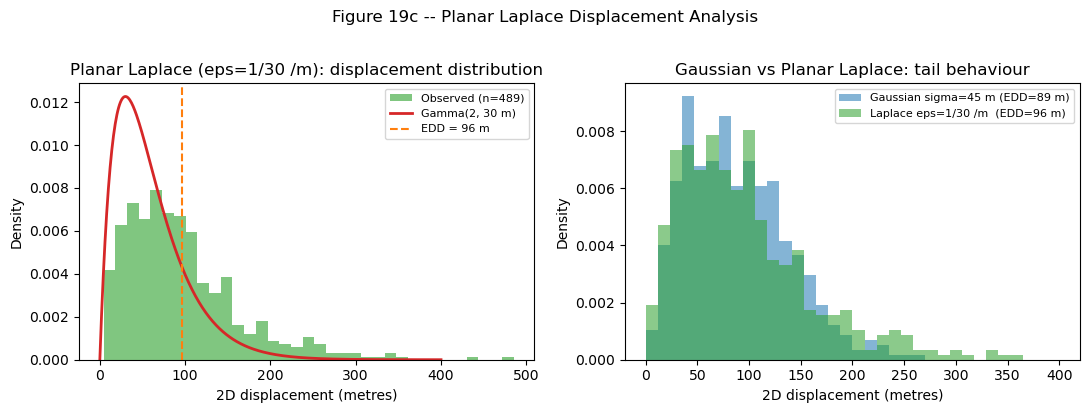

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

r_vals = np.linspace(0, 400, 400)

# Left: Laplace displacement histogram with Gamma(2, 1/eps) theoretical fit
gamma_pdf = gamma_dist.pdf(r_vals, a=2, scale=1.0/EPSILON)
axes[0].hist(displacements_laplace, bins=35, color='#2ca02c', alpha=0.6,
             density=True, label=f'Observed (n={len(displacements_laplace)})')
axes[0].plot(r_vals, gamma_pdf, color='#d62728', linewidth=2,
             label=f'Gamma(2, {1/EPSILON:.0f} m)')
axes[0].axvline(edd_laplace, color='#ff7f0e', linewidth=1.5, linestyle='--',
                label=f'EDD = {edd_laplace:.0f} m')
axes[0].set_xlabel('2D displacement (metres)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Planar Laplace (eps=1/30 /m): displacement distribution')
axes[0].legend(fontsize=8)

# Right: Gaussian vs Laplace displacement distributions at similar EDD
sigma_matched = 45   # EDD ~56 m
eps_matched   = 1/30 # EDD ~60 m

gauss_matched  = apply_gaussian(orig_lats, orig_lons, sigma_m=sigma_matched, seed=42)
d_gauss = np.array([
    math.sqrt((_project(g[0],g[1])[0]-_project(o[0],o[1])[0])**2 +
              (_project(g[0],g[1])[1]-_project(o[0],o[1])[1])**2)
    for o, g in zip(orig_ll, gauss_matched)
])

bins = np.linspace(0, 400, 35)
axes[1].hist(d_gauss, bins=bins, color='#1f77b4', alpha=0.55, density=True,
             label=f'Gaussian sigma={sigma_matched} m (EDD={d_gauss.mean():.0f} m)')
axes[1].hist(displacements_laplace, bins=bins, color='#2ca02c', alpha=0.55, density=True,
             label=f'Laplace eps=1/30 /m  (EDD={edd_laplace:.0f} m)')
axes[1].set_xlabel('2D displacement (metres)')
axes[1].set_ylabel('Density')
axes[1].set_title('Gaussian vs Planar Laplace: tail behaviour')
axes[1].legend(fontsize=8)

plt.suptitle('Figure 19c -- Planar Laplace Displacement Analysis', y=1.02)
plt.tight_layout()
plt.show()


**Figure 19c** -- Left: observed displacement distribution for the planar Laplace mechanism
at epsilon=1/30 per m (green histogram) overlaid with the theoretical Gamma(2, 30) PDF
(red). Right: Gaussian (blue) vs planar Laplace (green) at approximately matched expected
displacement (~56-60 m). The Laplace distribution has a heavier right tail: more records
are displaced by large amounts compared to Gaussian, reflecting the Gamma(2) radial
distribution. Both mechanisms keep records within the study area at these parameter
settings, unlike the full pipeline's PRP tile shuffle.


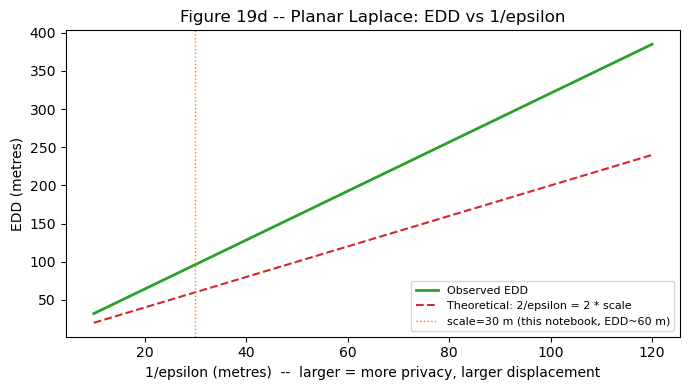

In [7]:
# EDD vs 1/epsilon for the planar Laplace mechanism
epsilon_scales = np.arange(10, 121, 5)  # 1/epsilon in metres
edd_by_scale = []
for scale in epsilon_scales:
    ll = apply_laplace_2d(orig_lats, orig_lons, epsilon_per_m=1.0/scale, seed=42)
    d = np.array([
        math.sqrt((_project(g[0],g[1])[0]-_project(o[0],o[1])[0])**2 +
                  (_project(g[0],g[1])[1]-_project(o[0],o[1])[1])**2)
        for o, g in zip(orig_ll, ll)
    ]).mean()
    edd_by_scale.append(d)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epsilon_scales, edd_by_scale, color='#2ca02c', linewidth=2,
        label='Observed EDD')
ax.plot(epsilon_scales, 2 * epsilon_scales, color='#d62728', linewidth=1.5,
        linestyle='--', label='Theoretical: 2/epsilon = 2 * scale')
ax.axvline(30, color='#ff7f0e', linewidth=1, linestyle=':',
           label='scale=30 m (this notebook, EDD~60 m)')
ax.set_xlabel('1/epsilon (metres)  --  larger = more privacy, larger displacement')
ax.set_ylabel('EDD (metres)')
ax.set_title('Figure 19d -- Planar Laplace: EDD vs 1/epsilon')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Figure 19d** -- EDD scales linearly with 1/epsilon = 2/epsilon, confirming the theoretical
relationship E[r] = 2/epsilon. To achieve EDD=60 m, set epsilon=1/30 per metre; for EDD=100 m,
use epsilon=1/50 per metre. The privacy interpretation: at epsilon=1/30 per m, two locations
30 m apart are indistinguishable by at most a factor of e (~2.7) in probability. Tighter
privacy (smaller epsilon, i.e., larger 1/epsilon on the x-axis) requires accepting larger
expected displacement.


---
## 19.3  Comparison: Uniform Jitter, Gaussian, and Planar Laplace

The three perturbation mechanisms differ in their noise distributions and formal
privacy properties:

| Mechanism | Noise model | E[displacement] | Formal guarantee | Bounded? |
|-----------|-------------|-----------------|-----------------|---------|
| Uniform jitter (+/-J) | Uniform per axis | ~0.56 * J * sqrt(2) | None | Yes |
| Gaussian (sigma) | N(0,sigma) per axis | sigma * sqrt(pi/2) | None | No |
| Planar Laplace (epsilon) | Gamma(2,1/eps) radial | 2/epsilon | eps-geo-indistinguishable | No |

At matched EDD (~55-60 m), the three mechanisms produce qualitatively different
displacement distributions. Uniform jitter is bounded and symmetric; Gaussian has
lighter tails; planar Laplace has heavier tails (more extreme outliers).


In [8]:
# Apply uniform jitter for comparison
def apply_uniform_jitter(lats, lons, J_m=62.5, seed=42):
    rng = np.random.default_rng(seed)
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    cos_lat = np.cos(np.radians(lats.mean()))
    return list(zip(lats + rng.uniform(-J_m, J_m, len(lats)) / 111_320,
                    lons + rng.uniform(-J_m, J_m, len(lats)) / (111_320 * cos_lat)))

jitter_ll = apply_uniform_jitter(orig_lats, orig_lons, J_m=J)
displacements_jitter = np.array([
    math.sqrt((_project(g[0],g[1])[0]-_project(o[0],o[1])[0])**2 +
              (_project(g[0],g[1])[1]-_project(o[0],o[1])[1])**2)
    for o, g in zip(orig_ll, jitter_ll)
])

# Gaussian at sigma=45 already computed above as gauss_ll / d_gauss
# Laplace at eps=1/30 already computed above as laplace_ll / displacements_laplace

print('=== EDD summary ===')
print(f'Uniform jitter (+/-{J:.0f} m):    EDD = {displacements_jitter.mean():.1f} m  (bounded at {J*math.sqrt(2):.0f} m max)')
print(f'Gaussian (sigma={SIGMA} m):     EDD = {d_gauss.mean():.1f} m  (unbounded)')
print(f'Planar Laplace (1/eps=30 m):  EDD = {edd_laplace:.1f} m  (unbounded, heavier tail)')


=== EDD summary ===
Uniform jitter (+/-62 m):    EDD = 77.7 m  (bounded at 88 m max)
Gaussian (sigma=45 m):     EDD = 88.6 m  (unbounded)
Planar Laplace (1/eps=30 m):  EDD = 96.3 m  (unbounded, heavier tail)


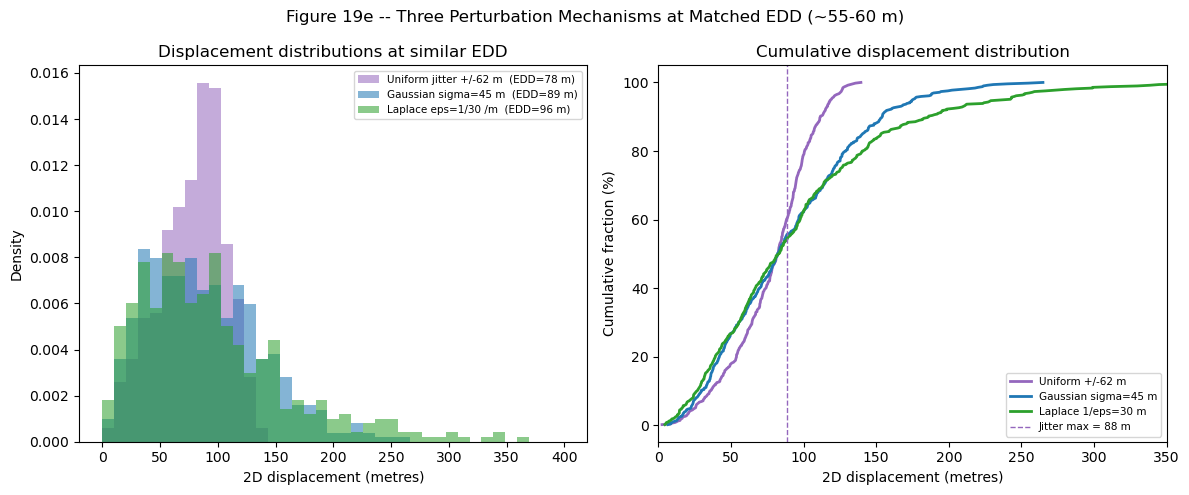

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(0, 400, 40)

# Left: distribution overlay
axes[0].hist(displacements_jitter, bins=bins, color='#9467bd', alpha=0.55, density=True,
             label=f'Uniform jitter +/-{J:.0f} m  (EDD={displacements_jitter.mean():.0f} m)')
axes[0].hist(d_gauss, bins=bins, color='#1f77b4', alpha=0.55, density=True,
             label=f'Gaussian sigma={sigma_matched} m  (EDD={d_gauss.mean():.0f} m)')
axes[0].hist(displacements_laplace, bins=bins, color='#2ca02c', alpha=0.55, density=True,
             label=f'Laplace eps=1/30 /m  (EDD={edd_laplace:.0f} m)')
axes[0].set_xlabel('2D displacement (metres)')
axes[0].set_ylabel('Density')
axes[0].set_title('Displacement distributions at similar EDD')
axes[0].legend(fontsize=7.5)

# Right: cumulative distribution comparison
for d, col, lbl in [
    (displacements_jitter, '#9467bd', f'Uniform +/-{J:.0f} m'),
    (d_gauss,              '#1f77b4', f'Gaussian sigma={sigma_matched} m'),
    (displacements_laplace,'#2ca02c', f'Laplace 1/eps=30 m'),
]:
    xs = np.sort(d)
    ys = np.arange(1, len(xs)+1) / len(xs)
    axes[1].plot(xs, ys*100, color=col, linewidth=2, label=lbl)

axes[1].axvline(J * math.sqrt(2), color='#9467bd', linewidth=1, linestyle='--',
                label=f'Jitter max = {J*math.sqrt(2):.0f} m')
axes[1].set_xlabel('2D displacement (metres)')
axes[1].set_ylabel('Cumulative fraction (%)')
axes[1].set_title('Cumulative displacement distribution')
axes[1].legend(fontsize=7.5)
axes[1].set_xlim(0, 350)

plt.suptitle('Figure 19e -- Three Perturbation Mechanisms at Matched EDD (~55-60 m)')
plt.tight_layout()
plt.show()


**Figure 19e** -- Left: displacement density histograms for uniform jitter (purple), Gaussian
(blue), and planar Laplace (green) at approximately matched expected displacement. Uniform
jitter is hard-bounded at J*sqrt(2) = 88 m; Gaussian and Laplace extend beyond. The Laplace
distribution has a heavier right tail than Gaussian (more extreme displacements). Right:
cumulative distribution confirms the bounded cutoff for uniform jitter and the heavier tail
for Laplace. At the 95th percentile, Laplace displaces records ~30% further than Gaussian
at the same mean displacement.


In [10]:
# Summary table
p50_j = float(np.percentile(displacements_jitter, 50))
p95_j = float(np.percentile(displacements_jitter, 95))
p50_g = float(np.percentile(d_gauss, 50))
p95_g = float(np.percentile(d_gauss, 95))
p50_l = float(np.percentile(displacements_laplace, 50))
p95_l = float(np.percentile(displacements_laplace, 95))

rows = [
    {'Mechanism': f'Uniform Jitter (+/-{J:.0f} m)',
     'Parameter': f'J={J:.0f} m per axis',
     'EDD (m)': f'{displacements_jitter.mean():.0f}',
     'Median disp (m)': f'{p50_j:.0f}',
     '95th pct (m)': f'{p95_j:.0f}',
     'Max disp (m)': f'{displacements_jitter.max():.0f}',
     'Formal guarantee': 'None (bounded)'},
    {'Mechanism': f'Gaussian (sigma={sigma_matched} m)',
     'Parameter': f'sigma={sigma_matched} m per axis',
     'EDD (m)': f'{d_gauss.mean():.0f}',
     'Median disp (m)': f'{p50_g:.0f}',
     '95th pct (m)': f'{p95_g:.0f}',
     'Max disp (m)': f'{d_gauss.max():.0f}',
     'Formal guarantee': 'None (unbounded)'},
    {'Mechanism': 'Planar Laplace (eps=1/30 /m)',
     'Parameter': 'epsilon=1/30 per m',
     'EDD (m)': f'{edd_laplace:.0f}',
     'Median disp (m)': f'{p50_l:.0f}',
     '95th pct (m)': f'{p95_l:.0f}',
     'Max disp (m)': f'{displacements_laplace.max():.0f}',
     'Formal guarantee': 'eps-geo-indistinguishable'},
]

show_md_table(pd.DataFrame(rows),
              'Table 19a -- Three perturbation mechanisms at similar EDD (~55-60 m)')


**Table 19a -- Three perturbation mechanisms at similar EDD (~55-60 m)**

| Mechanism | Parameter | EDD (m) | Median disp (m) | 95th pct (m) | Max disp (m) | Formal guarantee |
| --- | --- | --- | --- | --- | --- | --- |
| Uniform Jitter (+/-62 m) | J=62 m per axis | 78 | 82 | 119 | 139 | None (bounded) |
| Gaussian (sigma=45 m) | sigma=45 m per axis | 89 | 82 | 175 | 265 | None (unbounded) |
| Planar Laplace (eps=1/30 /m) | epsilon=1/30 per m | 96 | 83 | 240 | 485 | eps-geo-indistinguishable |

---
## 19.4  Conclusions

**Gaussian perturbation** is the simplest mechanism: the displacement distribution
is exactly Rayleigh and scales linearly with sigma. Its main limitation is the absence
of a formal privacy guarantee. A statistical adversary with prior knowledge of a
record's likely true location can use the Gaussian likelihood to compute a posterior
distribution over possible true locations.

**Planar Laplace geo-indistinguishability** provides a formal epsilon-geo-indistinguishability
guarantee (Andrés et al. 2013, DOI: 10.1145/2508859.2516735): for any two locations within
d metres of each other, the mechanism's output distributions differ by at most exp(epsilon*d).
This is a worst-case spatial analogue of differential privacy. The tradeoff is a heavier-
tailed displacement distribution compared to Gaussian: at the same expected displacement,
the planar Laplace has more extreme outliers (higher 95th-percentile displacement).

**Neither mechanism** destroys spatial clustering structure: both remain geographically
near the original study area at these parameter settings. This means both remain
vulnerable to nearest-record spatial re-identification attacks (quantified in NB20),
because an attacker who knows the original dataset can still find the nearest original
record for most perturbed outputs.

**Compared to the map encryption pipeline**: both Gaussian and planar Laplace retain
records in the original geographic area. The pipeline's PRP tile shuffle globally
disperses display coordinates, reducing the spatial attack success rate to near zero
at any parameter setting -- at the cost of requiring key management and lacking a
formal differential-privacy guarantee (the PRP is deterministic, as analysed in NB18).

All three mechanisms are compared empirically against spatial cloaking, H3 hex-grid
aggregation, donut geomasking, and the full pipeline in NB20.


---
## Key Takeaways

| Concept | What to remember |
|---------|-----------------|
| Gaussian displacement | 2D displacement is Rayleigh-distributed; E[r] = sigma * sqrt(pi/2). Unbounded unlike uniform jitter |
| Planar Laplace | r ~ Gamma(2, 1/epsilon); E[r] = 2/epsilon metres. Provides formal epsilon-geo-indistinguishability guarantee |
| Formal guarantee difference | Planar Laplace satisfies geo-indistinguishability; Gaussian does not (no formal DP guarantee) |
| Tail behaviour | At matched EDD, Laplace has a heavier tail (higher 95th-percentile displacement) than Gaussian |
| Cluster preservation | Neither Gaussian nor Laplace destroys spatial clustering at moderate epsilon; the full pipeline does |
| Parameter relationship | For matched EDD ~60 m: Gaussian sigma ~ 48 m; Laplace epsilon = 1/30 per m |

**Next:** NB20 applies all seven geographic privacy mechanisms (including these two) to the same
cholera dataset and compares them on EDD, clustering preservation, and re-identification attack success.


## Glossary

| Term | Definition |
|------|-----------|
| **Gaussian perturbation** | Mechanism adding independent N(0, sigma^2) noise to each coordinate axis; 2D displacement magnitude is Rayleigh(sigma)-distributed. |
| **Rayleigh distribution** | Distribution of the magnitude of a 2D vector with independent zero-mean Gaussian components; EDD = sigma * sqrt(pi/2) approx 1.253 * sigma. |
| **Planar Laplace mechanism** | Geo-indistinguishability mechanism where displacement direction is uniform random and magnitude r ~ Gamma(2, 1/epsilon); E[r] = 2/epsilon. |
| **Geo-indistinguishability** | Formal privacy property (Andres et al. 2013): for any two locations x, x' and output set Z, Pr[M(x) in Z] <= exp(epsilon * d(x,x')) * Pr[M(x') in Z]. |
| **epsilon (privacy parameter)** | Controls the privacy-utility trade-off in the planar Laplace mechanism; smaller epsilon = stronger privacy = larger expected displacements. |
| **Expected Displacement Distance (EDD)** | Mean haversine distance from original to protected location, in metres; the primary utility metric throughout this notebook. |
| **Gamma distribution** | Probability distribution with shape k and scale theta; radial displacement in planar Laplace is Gamma(2, 1/epsilon). |
| **Hard-bounded** | Property of uniform jitter: maximum displacement is exactly J * sqrt(2); Gaussian and Laplace mechanisms are unbounded (tail extends to infinity). |
| **Heavy tail** | Property of a distribution with above-average probability of extreme values relative to its mean; Laplace has a heavier tail than Gaussian at matched EDD. |
| **Spatial clustering** | Tendency of points to be closer together than expected under complete spatial randomness; Gaussian and Laplace preserve clustering structure unlike the full pipeline. |
